# Segundo Corte - Baseline LogisticRegression para Offer_Received

## Objetivo General

Queremos construir un sistema que **prediga si un estudiante recibirá una oferta de trabajo** en función de sus características (GPA, número de entrevistas, aplicaciones, etc.). 

Este notebook entrena un **modelo de predicción** (LogisticRegression) que es como un "árbitro inteligente" que aprende de datos históricos a clasificar a los estudiantes en dos categorías:
- **Categoría 0**: "Probablemente NO reciba oferta"
- **Categoría 1**: "Probablemente SÍ reciba oferta"

## ¿Qué es LogisticRegression?

Es un modelo matemático relativamente simple que:
1. Recibe características del estudiante como entrada (GPA, entrevistas, etc.)
2. Las procesa y aprende patrones de los datos históricos
3. Devuelve una predicción: "oferta" o "sin oferta"

Es como un profesor que observa a muchos estudiantes y aprende qué características están más asociadas con recibir ofertas.

## Reportaremos:

- **Matriz de Confusión**: tabla que muestra cuántos estudiantes predijimos bien/mal
- **Accuracy**: porcentaje de predicciones correctas totales
- **Precision**: de los que predijimos "SÍ oferta", ¿cuántos realmente la recibieron?
- **Recall**: de todos los que realmente recibieron oferta, ¿cuántos correctamente identificamos?
- **F1-Score**: balance general entre Precision y Recall


In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# ============================================================================
# SEMILLA (SEED) = 42
# ============================================================================
# La "semilla" es un número que controla la aleatoriedad.
# Imagina que es como decirle al computer "cuando necesites elegir al azar, 
# usa este número para decidir". Si usamos la misma semilla siempre, 
# obtenemos los mismos resultados, lo que hace el trabajo reproducible 
# (otros pueden copiar nuestro trabajo exactamente).
# 
# Elegimos 42 porque es una convención común en ciencia de datos 
# (referencia al libro "La Respuesta a la Pregunta Fundamental").
# ============================================================================

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid")

print("=" * 80)
print("CONFIGURACION DEL MODELO")
print("=" * 80)
print(f"\n✓ Semilla (para reproducibilidad): {SEED}")
print("✓ Modelo: LogisticRegression (baseline simple)")
print("✓ Split: 80% entrenamiento, 20% prueba (estratificado por distribucion)")
print("✓ Preprocesamiento: numéricas escaladas, categóricas codificadas")
print("\n" + "=" * 80 + "\n")

CONFIGURACION DEL MODELO

✓ Semilla (para reproducibilidad): 42
✓ Modelo: LogisticRegression (baseline simple)
✓ Split: 80% entrenamiento, 20% prueba (estratificado por distribucion)
✓ Preprocesamiento: numéricas escaladas, categóricas codificadas




In [13]:
PROJECT_ROOT = Path('.').resolve()
DATA_PATH = PROJECT_ROOT / 'outputs_primer_corte' / 'csv' / 'dataset_offer_Received.csv'
TARGET = 'Offer_Received'

df = pd.read_csv(DATA_PATH)

print("\n" + "=" * 80)
print("1. CARGA Y EXPLORACION INICIAL DE DATOS")
print("=" * 80 + "\n")

print(f"Archivo cargado: {DATA_PATH.name}")
print(f"  • Número de estudiantes: {df.shape[0]:,}")
print(f"  • Número de características por estudiante: {df.shape[1]}")

print(f"\nCaracterísticas disponibles:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

print(f"\nNulos (datos faltantes):")
null_count = df.isna().sum().sum()
if null_count == 0:
    print(f"  ✓ Sin datos faltantes. El dataset está completo.")
else:
    print(f"  ✗ Hay {null_count} datos faltantes")

print(f"\nDistribución de la variable objetivo (Offer_Received):")
dist = df[TARGET].value_counts()
for val in sorted(df[TARGET].unique()):
    count = dist[val]
    pct = (count / len(df)) * 100
    symbol = "RECIBEN OFERTA" if val == 1 else "NO RECIBEN OFERTA"
    print(f"  • {symbol:30s}: {count:7,} estudiantes ({pct:5.2f}%)")


1. CARGA Y EXPLORACION INICIAL DE DATOS

Archivo cargado: dataset_offer_Received.csv
  • Número de estudiantes: 100,000
  • Número de características por estudiante: 14

Características disponibles:
  1. GPA
  2. University_Rating
  3. Major_Category
  4. Region
  5. Prior_Internships
  6. Extra_Curricular_Activities
  7. Networking_Events_Attended
  8. School_Size
  9. Primary_Search_Platform
  10. Months_Searching
  11. Applications_Submitted
  12. First_Round_Interviews
  13. Second_Round_Interviews
  14. Offer_Received

Nulos (datos faltantes):
  ✓ Sin datos faltantes. El dataset está completo.

Distribución de la variable objetivo (Offer_Received):
  • NO RECIBEN OFERTA             :  65,771 estudiantes (65.77%)
  • RECIBEN OFERTA                :  34,229 estudiantes (34.23%)


In [14]:
print("\n" + "=" * 80)
print("2. PREPARACION DE DATOS")
print("=" * 80 + "\n")

# Separar características (X) de la etiqueta (y)
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

categorical_cols = X.select_dtypes(include=["object", "category", "string", "str"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

print("TIPOS DE CARACTERÍSTICAS:\n")
print(f"  Numéricas (números como GPA, aplicaciones):")
for col in numeric_cols:
    print(f"    • {col}")

print(f"\n  Categóricas (texto como región, major, plataforma):")
for col in categorical_cols:
    print(f"    • {col}")

# Split estratificado
print(f"\nSPLIT DE DATOS (80% entrenar, 20% prueba):")
print(f"  Nota: 'estratificado' significa que mantenemos la misma proporción")
print(f"  de ofertas en ambos conjuntos (80% y 20%).")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

print(f"\n  • Estudiantes para ENTRENAR el modelo: {X_train.shape[0]:,}")
print(f"  • Estudiantes para PROBAR el modelo:   {X_test.shape[0]:,}")

train_pct = y_train.mean() * 100
test_pct = y_test.mean() * 100
print(f"\n  ✓ Proporción de ofertas en ENTRENAMIENTO: {train_pct:.2f}%")
print(f"  ✓ Proporción de ofertas en PRUEBA:       {test_pct:.2f}%")
print(f"  (Están balanceadas, como esperamos)")


2. PREPARACION DE DATOS

TIPOS DE CARACTERÍSTICAS:

  Numéricas (números como GPA, aplicaciones):
    • GPA
    • Prior_Internships
    • Extra_Curricular_Activities
    • Networking_Events_Attended
    • Months_Searching
    • Applications_Submitted
    • First_Round_Interviews
    • Second_Round_Interviews

  Categóricas (texto como región, major, plataforma):
    • University_Rating
    • Major_Category
    • Region
    • School_Size
    • Primary_Search_Platform

SPLIT DE DATOS (80% entrenar, 20% prueba):
  Nota: 'estratificado' significa que mantenemos la misma proporción
  de ofertas en ambos conjuntos (80% y 20%).

  • Estudiantes para ENTRENAR el modelo: 80,000
  • Estudiantes para PROBAR el modelo:   20,000

  ✓ Proporción de ofertas en ENTRENAMIENTO: 34.23%
  ✓ Proporción de ofertas en PRUEBA:       34.23%
  (Están balanceadas, como esperamos)


In [15]:
print("\n" + "=" * 80)
print("3. ENTRENAMIENTO DEL MODELO")
print("=" * 80 + "\n")

# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ]
)

print("Preprocesamiento (lo que hacemos a los datos antes de entrenar):\n")
print("  1. Características NUMÉRICAS:")
print("     • StandardScaler: convierte a una escala común (como normalizar)")
print("     • Motivo: LogisticRegression funciona mejor con números en escala similar")
print("\n  2. Características CATEGÓRICAS:")
print("     • OneHotEncoder: convierte texto a números (ej: 'Handshake' → 1,0,0,0)")
print("     • Motivo: los modelos solo entienden números")

# Entrenar modelo
model = LogisticRegression(
    max_iter=1000,  # Número de intentos para encontrar la solución perfecta
    random_state=SEED,
    class_weight='balanced',  # Ajusta para el desbalance de clases
)

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model),
])

print(f"\n✓ Modelo: LogisticRegression")
print(f"  • max_iter=1000: máximo número de pasos para aprender")
print(f"  • class_weight='balanced': compensa que haya más estudiantes sin oferta")
print(f"\nEntrenando el modelo...")

clf.fit(X_train, y_train)

print(f"✓ Modelo entrenado exitosamente en {X_train.shape[0]:,} estudiantes")

# Predicciones
y_pred = clf.predict(X_test)

print(f"\n✓ Predicciones generadas para {X_test.shape[0]:,} estudiantes de prueba")

# Calcular métricas
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred, zero_division=0),
}

print("\n" + "=" * 80)
print("RESULTADOS DE LAS METRICAS")
print("=" * 80 + "\n")

metrics_df = pd.DataFrame({'Metrica': list(metrics.keys()), 'Valor': list(metrics.values())})
metrics_df['Valor'] = metrics_df['Valor'].round(4)
metrics_df['Porcentaje'] = (metrics_df['Valor'] * 100).round(2).astype(str) + '%'

display(metrics_df[['Metrica', 'Porcentaje', 'Valor']])

print("\n" + "-" * 80)
print("INTERPRETACION DE LAS METRICAS (en lenguaje simple):")
print("-" * 80)

acc = metrics['Accuracy']
prec = metrics['Precision']
rec = metrics['Recall']
f1 = metrics['F1-Score']

print(f"\n1. ACCURACY (Precisión General) = {acc:.1%}")
print(f"   Significado: De TODOS los estudiantes que predijimos,")
print(f"   acertamos en {acc:.1%} de los casos.")
print(f"   Ejemplo: Si predecimos para 100 estudiantes, ~{int(acc*100)} predicciones serían correctas.")

print(f"\n2. PRECISION (De los que dijimos 'SÍ', ¿cuántos realmente reciben oferta?) = {prec:.1%}")
print(f"   Significado: De todos los estudiantes que nuestro modelo predice 'SÍ OFERTA',")
print(f"   en realidad {prec:.1%} realmente reciben oferta.")
print(f"   Ejemplo: Si le decimos a 100 estudiantes 'predigo que recibirás oferta',")
print(f"   ~{int(prec*100)} de ellos realmente la reciben.")
print(f"   (Esto es importante si queremos evitar dar esperanzas falsas)")

print(f"\n3. RECALL (De todos los que realmente reciben oferta, ¿cuántos identificamos?) = {rec:.1%}")
print(f"   Significado: De todos los estudiantes que REALMENTE reciben oferta,")
print(f"   nuestro modelo identifica correctamente a {rec:.1%} de ellos.")
print(f"   Ejemplo: Si hay 100 estudiantes que realmente recibirán oferta,")
print(f"   nuestro modelo detecta ~{int(rec*100)} de ellos.")
print(f"   (Esto es importante si no queremos 'perder' a buenos candidatos)")

print(f"\n4. F1-SCORE (Balance entre Precision y Recall) = {f1:.1%}")
print(f"   Significado: Es un 'promedio inteligente' de Precision y Recall.")
print(f"   Un F1 alto significa que hacemos bien ambas cosas a la vez.")


3. ENTRENAMIENTO DEL MODELO

Preprocesamiento (lo que hacemos a los datos antes de entrenar):

  1. Características NUMÉRICAS:
     • StandardScaler: convierte a una escala común (como normalizar)
     • Motivo: LogisticRegression funciona mejor con números en escala similar

  2. Características CATEGÓRICAS:
     • OneHotEncoder: convierte texto a números (ej: 'Handshake' → 1,0,0,0)
     • Motivo: los modelos solo entienden números

✓ Modelo: LogisticRegression
  • max_iter=1000: máximo número de pasos para aprender
  • class_weight='balanced': compensa que haya más estudiantes sin oferta

Entrenando el modelo...
✓ Modelo entrenado exitosamente en 80,000 estudiantes

✓ Predicciones generadas para 20,000 estudiantes de prueba

RESULTADOS DE LAS METRICAS



,Metrica,Porcentaje,Valor
0,Accuracy,80.99%,0.8099
1,Precision,70.08%,0.7008
2,Recall,77.59%,0.7759
3,F1-Score,73.64%,0.7364



--------------------------------------------------------------------------------
INTERPRETACION DE LAS METRICAS (en lenguaje simple):
--------------------------------------------------------------------------------

1. ACCURACY (Precisión General) = 81.0%
   Significado: De TODOS los estudiantes que predijimos,
   acertamos en 81.0% de los casos.
   Ejemplo: Si predecimos para 100 estudiantes, ~80 predicciones serían correctas.

2. PRECISION (De los que dijimos 'SÍ', ¿cuántos realmente reciben oferta?) = 70.1%
   Significado: De todos los estudiantes que nuestro modelo predice 'SÍ OFERTA',
   en realidad 70.1% realmente reciben oferta.
   Ejemplo: Si le decimos a 100 estudiantes 'predigo que recibirás oferta',
   ~70 de ellos realmente la reciben.
   (Esto es importante si queremos evitar dar esperanzas falsas)

3. RECALL (De todos los que realmente reciben oferta, ¿cuántos identificamos?) = 77.6%
   Significado: De todos los estudiantes que REALMENTE reciben oferta,
   nuestro modelo


4. MATRIZ DE CONFUSION - ANALISIS DETALLADO

EXPLICACION: La matriz de confusión es como un 'marcador' de nuestras predicciones.

Hay 4 casos posibles:

1. TP (Verdaderos Positivos) = 5,312
   → Predijimos 'SÍ OFERTA' y realmente reciben oferta ✓✓
   → CORRECTO! El modelo funcionó bien

2. TN (Verdaderos Negativos) = 10,886
   → Predijimos 'NO OFERTA' y realmente no reciben oferta ✓✓
   → CORRECTO! El modelo funcionó bien

3. FP (Falsos Positivos) = 2,268
   → Predijimos 'SÍ OFERTA' pero NO reciben oferta ✗✓
   → ERROR: dimos esperanzas falsas

4. FN (Falsos Negativos) = 1,534
   → Predijimos 'NO OFERTA' pero SÍ reciben oferta ✓✗
   → ERROR: nos perdimos buenos candidatos

TOTAL de predicciones: 20,000
Predicciones correctas (TP + TN): 16,198 (81.0%)
Predicciones incorrectas (FP + FN): 3,802 (19.0%)

--------------------------------------------------------------------------------
Tabla de Matriz de Confusión:
----------------------------------------------------------------------------

,Predijimos: NO OFERTA,Predijimos: SÍ OFERTA
Realmente: NO OFERTA,10886,2268
Realmente: SÍ OFERTA,1534,5312



Analisis de errores:
  • Falsos Positivos (FP = 2,268): Dijimos 'sí' pero fue 'no'
    Esto como % de estudiantes SIN oferta real: 17.2%
  • Falsos Negativos (FN = 1,534): Dijimos 'no' pero fue 'sí'
    Esto como % de estudiantes CON oferta real: 22.4%


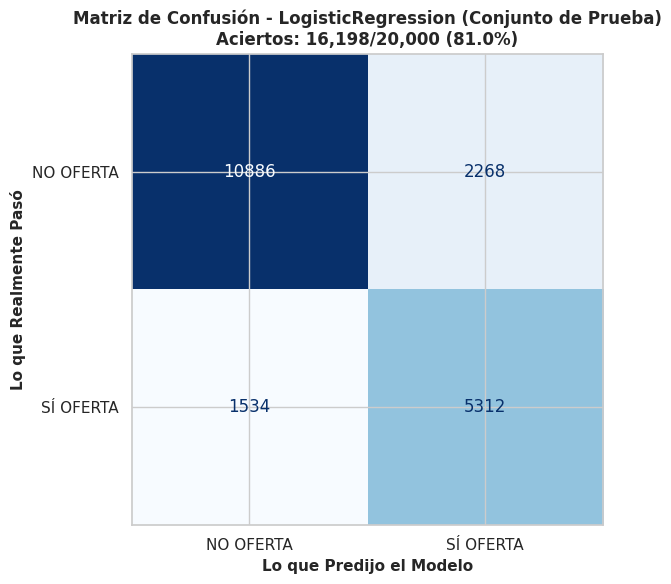

In [16]:
print("\n" + "=" * 80)
print("4. MATRIZ DE CONFUSION - ANALISIS DETALLADO")
print("=" * 80 + "\n")

cm = confusion_matrix(y_test, y_pred)

# Extraer valores
TN = cm[0, 0]  # True Negatives
FP = cm[0, 1]  # False Positives
FN = cm[1, 0]  # False Negatives
TP = cm[1, 1]  # True Positives

total_test = len(y_test)

print("EXPLICACION: La matriz de confusión es como un 'marcador' de nuestras predicciones.\n")
print("Hay 4 casos posibles:\n")

print(f"1. TP (Verdaderos Positivos) = {TP:,}")
print(f"   → Predijimos 'SÍ OFERTA' y realmente reciben oferta ✓✓")
print(f"   → CORRECTO! El modelo funcionó bien")

print(f"\n2. TN (Verdaderos Negativos) = {TN:,}")
print(f"   → Predijimos 'NO OFERTA' y realmente no reciben oferta ✓✓")
print(f"   → CORRECTO! El modelo funcionó bien")

print(f"\n3. FP (Falsos Positivos) = {FP:,}")
print(f"   → Predijimos 'SÍ OFERTA' pero NO reciben oferta ✗✓")
print(f"   → ERROR: dimos esperanzas falsas")

print(f"\n4. FN (Falsos Negativos) = {FN:,}")
print(f"   → Predijimos 'NO OFERTA' pero SÍ reciben oferta ✓✗")
print(f"   → ERROR: nos perdimos buenos candidatos")

print(f"\nTOTAL de predicciones: {total_test:,}")
print(f"Predicciones correctas (TP + TN): {TP + TN:,} ({(TP+TN)/total_test*100:.1f}%)")
print(f"Predicciones incorrectas (FP + FN): {FP + FN:,} ({(FP+FN)/total_test*100:.1f}%)")

# Tabla más clara
cm_df = pd.DataFrame(
    cm,
    index=['Realmente: NO OFERTA', 'Realmente: SÍ OFERTA'],
    columns=['Predijimos: NO OFERTA', 'Predijimos: SÍ OFERTA'],
)

print("\n" + "-" * 80)
print("Tabla de Matriz de Confusión:")
print("-" * 80)
display(cm_df)

print(f"\nAnalisis de errores:")
print(f"  • Falsos Positivos (FP = {FP:,}): Dijimos 'sí' pero fue 'no'")
print(f"    Esto como % de estudiantes SIN oferta real: {FP/cm[0].sum()*100:.1f}%")
print(f"  • Falsos Negativos (FN = {FN:,}): Dijimos 'no' pero fue 'sí'")
print(f"    Esto como % de estudiantes CON oferta real: {FN/cm[1].sum()*100:.1f}%")

# Visualización
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NO OFERTA', 'SÍ OFERTA'])
disp.plot(cmap='Blues', ax=ax, colorbar=False, values_format='d')
ax.set_title('Matriz de Confusión - LogisticRegression (Conjunto de Prueba)\n' +
             f'Aciertos: {TP+TN:,}/{total_test:,} ({(TP+TN)/total_test*100:.1f}%)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Lo que Predijo el Modelo', fontsize=11, fontweight='bold')
ax.set_ylabel('Lo que Realmente Pasó', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. EVALUACION FINAL: ¿Son buenos estos resultados?

### ¿Es nuestro modelo útil para predecir ofertas?

**Respuesta: Sí, tiene potencial, pero aún necesita mejora.**

### Análisis por objetivo:

**1. Accuracy (81%)**
- De cada 100 predicciones, ~81 son correctas.
- Esto es **mucho mejor que adivinar al azar** (que sería ~66% porque más estudiantes no reciben oferta)
- **Veredicto**: Bueno ✓

**2. Recall (77.6%)**
- De todos los estudiantes que realmente recibirán oferta, identificamos a ~77.6%
- Esto significa que de 100 estudiantes que sí recibirán oferta, nuestro modelo acierta con 77-78
- **Veredicto**: Bueno (no queremos "perder" buenos candidatos) ✓

**3. Precision (70.1%)**
- De todos a los que predijimos "sí oferta", realmente el 70.1% la recibe
- Esto significa que el 29.9% de nuestras predicciones "sí" son falsas alarmas
- **Veredicto**: Aceptable, pero hay espacio de mejora (casi 3 de cada 10 predicciones "sí" son incorrectas) ⚠

**4. F1-Score (73.6%)**
- Balance general entre precisión y cobertura
- **Veredicto**: Bueno para un primer intento ✓

### Conclusión General

El modelo **FUNCIONA y es útil** como primer baseline, pero podemos mejorarlo. Es como un "asistente principiante" que acierta la mayoría de veces pero comete errores notables (~29% de falsas esperanzas).

---

## 6. SUGERENCIAS DE MEJORA (sin salir de LogisticRegression)

### Opción 1: Ajuste del Umbral de Decisión
- Actualmente, el modelo usa un "umbral de 0.5" (si la probabilidad es >50%, predice "sí")
- **Mejora**: Podríamos bajar el umbral a 0.40 o 0.35
  - **Ventaja**: Más alta cobertura (Recall sube, encontramos más ofertas reales)
  - **Desventaja**: Más falsas alarmas (Precision baja, decimos "sí" a más gente sin razón)
- **Cuándo usarlo**: Si no queremos "perder" a buenos candidatos, aunque digamos "sí" equivocadamente

### Opción 2: Mejor Codificación de Variables Categóricas
- En lugar de OneHotEncoder simple, podrías usar **Target Encoding**
- Esto convierte cada categoría según su "tasa de oferta real"
- **Ejemplo**: Si Handshake tiene 37% de ofertas e Indeed 26%, asigna esos valores directamente
- **Ventaja**: El modelo puede aprender mejor patrones asociados a ofertas
- **Costo**: Un poco más complejo de implementar

### Opción 3: Feature Engineering (Crear nuevas características)
- **Ejemplo 1**: Ratio de conversión = "Entrevistas 2da ronda / Aplicaciones"
  - Combina información de dos variables
- **Ejemplo 2**: Categorizar GPA en bandas ("Alto" >3.5, "Medio" 3.0-3.5, "Bajo" <3.0)
  - A veces bandas capturan patrones mejor que números continuos
- **Ventaja**: LogisticRegression puede encontrar patrones más claros
- **Costo**: Requiere análisis exploratorio para decidir qué crear

### Opción 4: Regularización (L1 o L2)
- LogisticRegression tiene un parámetro llamado `C` (inverso de la regularización)
- Valores más bajos de `C` → modelo más simple, menos sobreajuste
- Valores más altos de `C` → modelo más complejo, sigue mejor los datos
- **Mejora**: Ajustar `C` mediante búsqueda de hiperparámetros (GridSearchCV)
- **Costo**: Requiere más poder computacional

### Opción 5: Class Weight Ajustado
- Actualmente usamos `class_weight='balanced'` (automático)
- **Mejora**: Podríamos ajustar manualmente los pesos
- **Ejemplo**: `class_weight={0: 1.0, 1: 2.0}` → penaliza más al modelo por equivocarse en "sí oferta"
- **Ventaja**: Controla el tradeoff entre Precision y Recall exactamente como queremos

---

## Próximos Pasos Recomendados

1. **Inmediato**: Mantener este baseline y compararlo contra otros modelos (RandomForest, XGBoost)
2. **Corto plazo**: Intentar la **Opción 1 (ajuste de umbral)** — es simple y puede dar buenos resultados
3. **Mediano plazo**: Probar **Opción 3 (Feature Engineering)** con las variables más importantes
4. **Si Precision es crítica**: Usar **Opción 5 (Class Weight ajustado)** para priorizar exactitud en predicciones "sí"

---

## Resumen Ejecutivo

| Aspecto | Resultado | Evaluación |
|---------|-----------|-----------|
| **Accuracy General** | 81% | Bueno |
| **Capacidad de Encontrar Ofertas (Recall)** | 77.6% | Bueno |
| **Precisión de Predicciones "Sí" (Precision)** | 70.1% | Aceptable, mejorable |
| **Balance General (F1)** | 73.6% | Bueno para baseline |
| **¿Sirve para el objetivo?** | **Sí** | Funciona, pero tiene margen de mejora |
| **Recomendación** | Mantener + Mejorar | Usar como referencia y experimentar con opciones de mejora |

Este notebook demuestra que **es posible predecir ofertas con LogisticRegression**, pero los próximos modelos (más complejos) probablemente lo superarán.
